# DNSC 8328 Assignment 3 — Python code

Runs top to bottom in a fresh session on the `hw3-env` kernel (packages in `requirements.txt`),
with `Long_Distance_Carrier Data.xls` in the same folder.

## Setup

In [27]:
import contextlib
import io
import logging
import warnings

warnings.filterwarnings("ignore")                        # tqdm/ipywidgets notice on import

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import bnlearn as bn
import pgmpy
from bnlearn.utils import infer_data_type
from matplotlib.patches import Ellipse
from pgmpy.parameter_estimator import DiscreteBayesianEstimator
from pgmpy.utils import get_state_counts
from pgmpy.inference import ApproxInference
from pgmpy.structure_score import BDeu, BIC
from math import lgamma

logging.getLogger("bnlearn").setLevel(logging.WARNING)   # bnlearn logs at INFO to stderr

print("bnlearn", bn.__version__)
print("pgmpy  ", pgmpy.__version__)

bnlearn 1.0.0
pgmpy   1.1.2


In [28]:
SEED = 8328
np.random.seed(SEED)

DATA_FILE = "Long_Distance_Carrier Data.xls"
STATES = {"Y": ["A", "B", "C"], "X1": ["low", "high"],
          "X2": ["low", "high"], "X3": ["low", "high"]}
PROFILE = {"X1": "high", "X2": "low", "X3": "high"}      # customer of B2.3
ALPHA = 12                                               # global precision

M_EDGES = {                                              # candidate models of B4
    "M1": [("Y", "X1"), ("Y", "X2"), ("Y", "X3"), ("X1", "X2"), ("X1", "X3"), ("X2", "X3")],
    "M2": [("Y", "X1"), ("Y", "X2"), ("Y", "X3")],
    "M3": [("Y", "X1"), ("Y", "X2"), ("Y", "X3"), ("X1", "X2")],
    "M4": [("Y", "X1"), ("Y", "X2"), ("Y", "X3"), ("X1", "X3")],
    "M5": [("Y", "X1"), ("Y", "X2"), ("Y", "X3"), ("X2", "X3")],
}
nb_edges = M_EDGES["M2"]                                 # naive Bayes

In [29]:
def quiet(func, *args, **kwargs):
    # run a bnlearn call without its placeholder-CPD printout
    with contextlib.redirect_stdout(io.StringIO()):
        return func(*args, **kwargs)


def load_data(path=DATA_FILE):
    # read the survey sheet; recode Y 1,2,3 -> A,B,C and X 0,1 -> low,high
    df = pd.read_excel(path, sheet_name="Data")
    df["Y"] = df["Y"].map({1: "A", 2: "B", 3: "C"})
    for col in ["X1", "X2", "X3"]:
        df[col] = df[col].map({0: "low", 1: "high"})
    df = df[["Y", "X1", "X2", "X3"]]
    assert df.notna().all().all(), "unmapped codes in the data"
    for col, levels in STATES.items():
        df[col] = pd.Categorical(df[col], categories=levels)
    return df


def free_parameters(edges, states=STATES):
    # sum over nodes of (C_i - 1) * Q_i
    total = 0
    for node, levels in states.items():
        parents = [p for p, c in edges if c == node]
        q = int(np.prod([len(states[p]) for p in parents])) if parents else 1
        total += (len(levels) - 1) * q
    return total


def dir_str(v):
    return "Dir(" + ", ".join(f"{x:g}" for x in v) + ")"


POS = {"Y": (0.5, 0.78), "X1": (0.16, 0.22), "X2": (0.5, 0.22), "X3": (0.84, 0.22)}
LABELS = {"Y": "$Y$", "X1": "$X_1$", "X2": "$X_2$", "X3": "$X_3$"}
NODE_W, NODE_H = 0.19, 0.26


def draw_dag(edges, title=None, ax=None):
    # DAG over Y and the attributes; edges between attributes bend below the row
    if ax is None:
        _, ax = plt.subplots(figsize=(3.6, 2.4))
    for node, (x, y) in POS.items():
        ax.add_patch(Ellipse((x, y), NODE_W, NODE_H, facecolor="white",
                             edgecolor="black", linewidth=0.9, zorder=2))
        ax.text(x, y, LABELS[node], ha="center", va="center", fontsize=11, zorder=3)
    for parent, child in edges:
        curved = parent != "Y"
        ax.annotate("", xy=POS[child], xytext=POS[parent], zorder=1,
                    arrowprops=dict(arrowstyle="-|>", color="black", linewidth=0.9,
                                    mutation_scale=9, shrinkA=13, shrinkB=13,
                                    connectionstyle="arc3,rad=-0.5" if curved else "arc3"))
    if title:
        ax.set_title(title, fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0.02, 0.98)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax

## B1 Exploration

### B1.1 Read and recode the data

In [30]:
data = load_data()
print(len(data), "responses")
data.dtypes

877 responses


Y     category
X1    category
X2    category
X3    category
dtype: object

In [31]:
# bnlearn's discrete/continuous rule (bnlearn.utils.infer_data_type)
raw = pd.read_excel(DATA_FILE, sheet_name="Data")[["Y", "X1", "X2", "X3"]]
print("cardinality threshold:", max(10, int(0.05 * len(raw))))
print("raw integer codes    :", infer_data_type(raw)["dtype"])
print("recoded data         :", infer_data_type(data)["dtype"])
print("X1 stored as float   :", infer_data_type(raw.astype({"X1": float}))["dtype"])

cardinality threshold: 43
raw integer codes    : discrete
recoded data         : discrete
X1 stored as float   : mixed


### B1.2 The four-way contingency table

In [32]:
four_way = (pd.crosstab([data["X1"], data["X2"], data["X3"]], data["Y"])
            .reindex(columns=STATES["Y"]))
four_way["total"] = four_way.sum(axis=1)
four_way

Y                 A    B   C  total
X1   X2   X3                       
low  low  low   113   98  73    284
          high   35   18  17     70
     high low    19    8   7     34
          high   36    9  15     60
high low  low    21   60   5     86
          high   27   66   9    102
     high low     8    8   6     22
          high   74  113  32    219

### B1.3 The cross-tabulations of Y with each X

In [33]:
for col in ["X1", "X2", "X3"]:
    counts = pd.crosstab(data["Y"], data[col])
    props = pd.crosstab(data["Y"], data[col], normalize="columns").round(4)
    print(f"Y by {col}: counts and p(Y | {col})")
    display(pd.concat({"count": counts, "p(Y|x)": props}, axis=1))

Y by X1: counts and p(Y | X1)


count       p(Y|x)        
X1   low high     low    high
Y                            
A    203  130  0.4531  0.3030
B    133  247  0.2969  0.5758
C    112   52  0.2500  0.1212

Y by X2: counts and p(Y | X2)


count       p(Y|x)        
X2   low high     low    high
Y                            
A    196  137  0.3616  0.4090
B    242  138  0.4465  0.4119
C    104   60  0.1919  0.1791

Y by X3: counts and p(Y | X3)


count       p(Y|x)        
X3   low high     low    high
Y                            
A    161  172  0.3779  0.3814
B    174  206  0.4085  0.4568
C     91   73  0.2136  0.1619

### B1.4 Which attribute appears most related to the preferred provider?

In [34]:
# p(Y | X_i) against the marginal p(Y), and the largest change from low to high
baseline = data["Y"].value_counts(normalize=True).reindex(STATES["Y"])
blocks = {("", "p(Y)"): baseline}
for col in ["X1", "X2", "X3"]:
    props = pd.crosstab(data["Y"], data[col], normalize="columns")
    for level in STATES[col]:
        blocks[(col, level)] = props[level]
comparison = pd.DataFrame(blocks).round(4)
comparison.columns = pd.MultiIndex.from_tuples(comparison.columns)
display(comparison)

for col in ["X1", "X2", "X3"]:
    gap = (comparison[col]["high"] - comparison[col]["low"]).abs()
    print(f"largest change, {col}: {gap.max():.4f} (provider {gap.idxmax()})")

X1              X2              X3        
     p(Y)     low    high     low    high     low    high
Y                                                        
A  0.3797  0.4531  0.3030  0.3616  0.4090  0.3779  0.3814
B  0.4333  0.2969  0.5758  0.4465  0.4119  0.4085  0.4568
C  0.1870  0.2500  0.1212  0.1919  0.1791  0.2136  0.1619

largest change, X1: 0.2789 (provider B)
largest change, X2: 0.0474 (provider A)
largest change, X3: 0.0517 (provider C)


## B2 Naive Bayes by hand, then in software

### B2.1 The naive Bayes DAG, its factorization and its parameter vectors

free parameters: 11


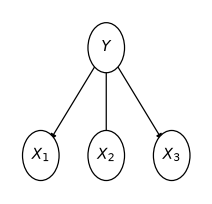

In [35]:
ax = draw_dag(nb_edges)
ax.figure.savefig("fig_nb_dag.pdf", bbox_inches="tight")
print("free parameters:", free_parameters(nb_edges))

### B2.2–B2.3

By hand; reproduced in B2.4.

### B2.4 Reproduce steps 2 and 3 in software, then repeat with the default settings

In [36]:
# step 2: posterior Dirichlet = BDeu pseudo-counts alpha_ijk + counts N_ijk, both taken from
# pgmpy (DiscreteBayesianEstimator normalises this sum into the fitted CPD)
nb_model = quiet(bn.make_DAG, nb_edges)["model"]
for i, node in enumerate(["Y", "X1", "X2", "X3"], start=1):
    prior, parents, _, _ = DiscreteBayesianEstimator._resolve_pseudo_counts(
        nb_model, STATES, node, "BDeu", ALPHA, None)
    counts = get_state_counts(data=data, state_names=STATES, variable=node, parents=parents)
    posterior = counts.to_numpy() + prior
    if not parents:
        print(f"{'theta_' + str(i):<9}{node:<12}prior {dir_str(prior[:, 0]):<15}"
              f"posterior {dir_str(posterior[:, 0])}")
    for j, cls in enumerate(STATES["Y"] if parents else []):
        print(f"{'theta_' + str(i) + str(j + 1):<9}{node + ' | Y = ' + cls:<12}"
              f"prior {dir_str(prior[:, j]):<15}posterior {dir_str(posterior[:, j])}")

theta_1  Y           prior Dir(4, 4, 4)   posterior Dir(337, 384, 168)
theta_21 X1 | Y = A  prior Dir(2, 2)      posterior Dir(205, 132)
theta_22 X1 | Y = B  prior Dir(2, 2)      posterior Dir(135, 249)
theta_23 X1 | Y = C  prior Dir(2, 2)      posterior Dir(114, 54)
theta_31 X2 | Y = A  prior Dir(2, 2)      posterior Dir(198, 139)
theta_32 X2 | Y = B  prior Dir(2, 2)      posterior Dir(244, 140)
theta_33 X2 | Y = C  prior Dir(2, 2)      posterior Dir(106, 62)
theta_41 X3 | Y = A  prior Dir(2, 2)      posterior Dir(163, 174)
theta_42 X3 | Y = B  prior Dir(2, 2)      posterior Dir(176, 208)
theta_43 X3 | Y = C  prior Dir(2, 2)      posterior Dir(93, 75)


In [37]:
# step 3: fit at alpha = 12 through pgmpy, classify the customer with bnlearn
DAG = quiet(bn.make_DAG, nb_edges)
DAG["model"].fit(data, estimator=DiscreteBayesianEstimator(
    prior_type="BDeu", equivalent_sample_size=ALPHA))
query_12 = quiet(bn.inference.fit, DAG, variables=["Y"], evidence=PROFILE)
print(query_12.df.round(4).to_string(index=False))

Y      p
A 0.2841
B 0.6080
C 0.1079


In [38]:
# default settings: bnlearn hard-codes equivalent_sample_size=1000
default_fit = quiet(bn.parameter_learning.fit, quiet(bn.make_DAG, nb_edges), data,
                    methodtype="bayes")
query_default = quiet(bn.inference.fit, default_fit, variables=["Y"], evidence=PROFILE)
print(query_default.df.round(4).to_string(index=False))

Y      p
A 0.3118
B 0.4704
C 0.2179


## B3 Prior sensitivity

In [39]:
alphas = [1, 12, 100, 1000]
sensitivity = {}
for a in alphas:
    dag_a = quiet(bn.make_DAG, nb_edges)
    dag_a["model"].fit(data, estimator=DiscreteBayesianEstimator(
        prior_type="BDeu", equivalent_sample_size=a))
    query_a = quiet(bn.inference.fit, dag_a, variables=["Y"], evidence=PROFILE)
    sensitivity[a] = query_a.df.set_index("Y")["p"]

sensitivity = pd.DataFrame(sensitivity).T.round(4)
sensitivity.index.name = "alpha"
sensitivity

Y,A,B,C
alpha,,,
1,0.2834,0.6111,0.1055
12,0.2841,0.6080,0.1079
100,0.2888,0.5855,0.1257
1000,0.3118,0.4704,0.2179


## B4 Five candidate classifiers

### Setup

In [40]:
import itertools


SEED = 8328
np.random.seed(SEED)

DATA_FILE = "Long_Distance_Carrier Data.xls"
STATES = {"Y": ["A", "B", "C"], "X1": ["low", "high"],
          "X2": ["low", "high"], "X3": ["low", "high"]}
PROFILE = {"X1": "high", "X2": "low", "X3": "high"}      # customer of B2.3
ALPHA = 12                                               # global precision
N_SAMPLES = 10000                                        # ApproxInference sample size

M_EDGES = {
    "M1": [("Y", "X1"), ("Y", "X2"), ("Y", "X3"), ("X1", "X2"), ("X1", "X3"), ("X2", "X3")],
    "M2": [("Y", "X1"), ("Y", "X2"), ("Y", "X3")],
    "M3": [("Y", "X1"), ("Y", "X2"), ("Y", "X3"), ("X1", "X2")],
    "M4": [("Y", "X1"), ("Y", "X2"), ("Y", "X3"), ("X1", "X3")],
    "M5": [("Y", "X1"), ("Y", "X2"), ("Y", "X3"), ("X2", "X3")],
}
MODELS = list(M_EDGES)
NODES = ["Y", "X1", "X2", "X3"]
ATTRS = ["X1", "X2", "X3"]


def quiet(func, *args, **kwargs):
    # run a bnlearn call without its placeholder-CPD printout or progress bar
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        return func(*args, **kwargs)


def load_data(path=DATA_FILE):
    # read the survey sheet; recode Y 1,2,3 -> A,B,C and X 0,1 -> low,high
    df = pd.read_excel(path, sheet_name="Data")
    df["Y"] = df["Y"].map({1: "A", 2: "B", 3: "C"})
    for col in ATTRS:
        df[col] = df[col].map({0: "low", 1: "high"})
    df = df[["Y", "X1", "X2", "X3"]]
    assert df.notna().all().all(), "unmapped codes in the data"
    for col, levels in STATES.items():
        df[col] = pd.Categorical(df[col], categories=levels)
    return df


def free_parameters(edges, states=STATES):
    # sum over nodes of (C_i - 1) * Q_i
    total = 0
    for node, levels in states.items():
        parents = [p for p, c in edges if c == node]
        q = int(np.prod([len(states[p]) for p in parents])) if parents else 1
        total += (len(levels) - 1) * q
    return total


def parents_of(edges, node):
    # parents in the fixed node order, so parent configurations print consistently
    return [p for p in NODES if (p, node) in edges]


def dir_str(v):
    return "Dir(" + ", ".join(f"{x:g}" for x in v) + ")"


def tag(name):
    print(f"\n=== {name} ===")


POS = {"Y": (0.5, 0.78), "X1": (0.16, 0.22), "X2": (0.5, 0.22), "X3": (0.84, 0.22)}
LABELS = {"Y": "$Y$", "X1": "$X_1$", "X2": "$X_2$", "X3": "$X_3$"}
NODE_W, NODE_H = 0.19, 0.26


def draw_dag(edges, title=None, ax=None):
    # DAG over Y and the attributes; edges between attributes bend below the row
    if ax is None:
        _, ax = plt.subplots(figsize=(3.6, 2.4))
    for node, (x, y) in POS.items():
        ax.add_patch(Ellipse((x, y), NODE_W, NODE_H, facecolor="white",
                             edgecolor="black", linewidth=0.9, zorder=2))
        ax.text(x, y, LABELS[node], ha="center", va="center", fontsize=11, zorder=3)
    for parent, child in edges:
        curved = parent != "Y"
        ax.annotate("", xy=POS[child], xytext=POS[parent], zorder=1,
                    arrowprops=dict(arrowstyle="-|>", color="black", linewidth=0.9,
                                    mutation_scale=9, shrinkA=13, shrinkB=13,
                                    connectionstyle="arc3,rad=-0.5" if curved else "arc3"))
    if title:
        ax.set_title(title, fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0.02, 0.98)
    ax.set_aspect("equal")
    ax.axis("off")
    return ax


data = load_data()
print(len(data), "responses")

# the 8 attribute profiles, in the row order of the B1.2 contingency table
PROFILES = [dict(zip(ATTRS, combo)) for combo in itertools.product(["low", "high"], repeat=3)]


ALPHA = 12                                               # global precision
N_SAMPLES = 10000  

def profile_label(p):
    return "/".join(p[a] for a in ATTRS)

877 responses


### 4.1 Factorization

In [41]:
fig, axes = plt.subplots(1, 5, figsize=(15, 2.6))
for ax, (name, edges) in zip(axes, M_EDGES.items()):
    draw_dag(edges, title=name, ax=ax)
fig.savefig("b4_five_dags.pdf", bbox_inches="tight")
plt.close(fig)

for name, edges in M_EDGES.items():
    factors = []
    for node in NODES:
        pa = parents_of(edges, node)
        factors.append(f"p({node.lower()} | {', '.join(p.lower() for p in pa)})" if pa
                       else f"p({node.lower()})")
    print(f"{name}: p(y, x1, x2, x3) = " + " ".join(factors)
          + f"    [{free_parameters(edges)} free parameters]")
    for node in NODES:
        pa = parents_of(edges, node)
        if pa:
            configs = list(itertools.product(*[STATES[p] for p in pa]))
            shown = ", ".join("(" + ",".join(c) + ")" for c in configs)
            print(f"    {node}: parents {tuple(pa)}, Q = {len(configs)}: {shown}")
        else:
            print(f"    {node}: no parents, Q = 1")

M1: p(y, x1, x2, x3) = p(y) p(x1 | y) p(x2 | y, x1) p(x3 | y, x1, x2)    [23 free parameters]
    Y: no parents, Q = 1
    X1: parents ('Y',), Q = 3: (A), (B), (C)
    X2: parents ('Y', 'X1'), Q = 6: (A,low), (A,high), (B,low), (B,high), (C,low), (C,high)
    X3: parents ('Y', 'X1', 'X2'), Q = 12: (A,low,low), (A,low,high), (A,high,low), (A,high,high), (B,low,low), (B,low,high), (B,high,low), (B,high,high), (C,low,low), (C,low,high), (C,high,low), (C,high,high)
M2: p(y, x1, x2, x3) = p(y) p(x1 | y) p(x2 | y) p(x3 | y)    [11 free parameters]
    Y: no parents, Q = 1
    X1: parents ('Y',), Q = 3: (A), (B), (C)
    X2: parents ('Y',), Q = 3: (A), (B), (C)
    X3: parents ('Y',), Q = 3: (A), (B), (C)
M3: p(y, x1, x2, x3) = p(y) p(x1 | y) p(x2 | y, x1) p(x3 | y)    [14 free parameters]
    Y: no parents, Q = 1
    X1: parents ('Y',), Q = 3: (A), (B), (C)
    X2: parents ('Y', 'X1'), Q = 6: (A,low), (A,high), (B,low), (B,high), (C,low), (C,high)
    X3: parents ('Y',), Q = 3: (A), (B), (C)

### B4.2a Estimation at alpha = 12, and the Dirichlet posteriors of M1

In [42]:
def fit_model(edges, alpha=ALPHA):
    # build the DAG with bnlearn, fit posterior-mean CPDs with BDeu at the given alpha
    dag = quiet(bn.make_DAG, edges)
    dag["model"].fit(data, estimator=DiscreteBayesianEstimator(
        prior_type="BDeu", equivalent_sample_size=alpha))
    return dag


fitted = {name: fit_model(edges) for name, edges in M_EDGES.items()}


def dirichlet_posteriors(name):
    # posterior Dir(alpha_ijk + N_ijk) per parent configuration j, as on slide 36
    model = fitted[name]["model"]
    rows = []
    for node in NODES:
        prior, parents, _, _ = DiscreteBayesianEstimator._resolve_pseudo_counts(
            model, STATES, node, "BDeu", ALPHA, None)
        counts = get_state_counts(data=data, state_names=STATES, variable=node, parents=parents)
        posterior = counts.to_numpy() + prior
        for j, config in enumerate(counts.columns):
            config = config if isinstance(config, tuple) else (config,)
            given = ", ".join(f"{p}={s}" for p, s in zip(parents, config)) if parents else "-"
            rows.append({"node": node, "parents = config": given,
                         "counts": tuple(int(c) for c in counts.to_numpy()[:, j]),
                         "prior": dir_str(prior[:, j]),
                         "posterior": dir_str(posterior[:, j])})
    return pd.DataFrame(rows)


tag("B4.2a Dirichlet posteriors, M1 (alpha = 12)")
print("state order: Y", STATES["Y"], " X", STATES["X1"])
print(dirichlet_posteriors("M1").to_string(index=False))

tag("B4.2a check: M2 reproduces the B2.3 customer")
m2_check = quiet(bn.inference.fit, fitted["M2"], variables=["Y"], evidence=PROFILE)
print(m2_check.df.round(4).to_string(index=False))
expected = np.array([0.2841, 0.6080, 0.1079])
assert np.allclose(m2_check.df.set_index("Y").loc[STATES["Y"], "p"].round(4), expected), \
    "M2 does not match A's B2.3 numbers"
print("matches A's B2.3 result (0.2841, 0.6080, 0.1079)")



=== B4.2a Dirichlet posteriors, M1 (alpha = 12) ===
state order: Y ['A', 'B', 'C']  X ['low', 'high']
node      parents = config          counts         prior          posterior
   Y                     - (333, 380, 164)  Dir(4, 4, 4) Dir(337, 384, 168)
  X1                   Y=A      (203, 130)     Dir(2, 2)      Dir(205, 132)
  X1                   Y=B      (133, 247)     Dir(2, 2)      Dir(135, 249)
  X1                   Y=C       (112, 52)     Dir(2, 2)       Dir(114, 54)
  X2           X1=low, Y=A       (148, 55)     Dir(1, 1)       Dir(149, 56)
  X2           X1=low, Y=B       (116, 17)     Dir(1, 1)       Dir(117, 18)
  X2           X1=low, Y=C        (90, 22)     Dir(1, 1)        Dir(91, 23)
  X2          X1=high, Y=A        (48, 82)     Dir(1, 1)        Dir(49, 83)
  X2          X1=high, Y=B      (126, 121)     Dir(1, 1)      Dir(127, 122)
  X2          X1=high, Y=C        (14, 38)     Dir(1, 1)        Dir(15, 39)
  X3   X1=low, X2=low, Y=A       (113, 35) Dir(0.5, 0.5)   Di

 ### B4.2b Exact vs approximate inference for all 8 profiles

In [43]:
def exact_probs(name, profile):
    # variable elimination through bnlearn; reorder to A, B, C explicitly
    q = quiet(bn.inference.fit, fitted[name], variables=["Y"], evidence=profile)
    return q.df.set_index("Y")["p"].reindex(STATES["Y"]).to_numpy()


def approx_probs(name, profile, seed=SEED, n_samples=N_SAMPLES):
    # rejection sampling: forward-sample the network, keep the draws that match the
    # evidence, report the share of A, B, C among them
    infer = ApproxInference(fitted[name]["model"])
    f = infer.query(variables=["Y"], evidence=profile, n_samples=n_samples, seed=seed,
                    state_names={"Y": STATES["Y"]}, show_progress=False)
    assert f.state_names["Y"] == STATES["Y"]
    return f.values


exact = {}
approx = {}
for name in MODELS:
    for p in PROFILES:
        exact[(name, profile_label(p))] = exact_probs(name, p)
        approx[(name, profile_label(p))] = approx_probs(name, p)

# ties are broken toward the class that is more common in the data (B, then A, then C);
# idxmax alone would pick a class by floating-point noise when two probabilities are equal
TIE_ORDER = list(data["Y"].value_counts().index.astype(str))


def predict_class(row, tol=1e-9):
    top = [y for y in TIE_ORDER if row[y] >= row[STATES["Y"]].max() - tol]
    return top[0]


def n_tied(row, tol=1e-9):
    return int((row[STATES["Y"]] >= row[STATES["Y"]].max() - tol).sum())


exact_df = pd.DataFrame(exact, index=STATES["Y"]).T
exact_df.index.names = ["model", "X1/X2/X3"]
exact_df["pred"] = exact_df.apply(predict_class, axis=1)
exact_df["tied"] = exact_df.apply(n_tied, axis=1) > 1
approx_df = pd.DataFrame(approx, index=STATES["Y"]).T
approx_df.index.names = ["model", "X1/X2/X3"]
approx_df["pred"] = approx_df.apply(predict_class, axis=1)

tag("B4.2b exact (variable elimination) vs approximate (rejection sampling, seed 8328)")
side = pd.concat({"exact": exact_df, "approx": approx_df}, axis=1)
diff = (approx_df[STATES["Y"]] - exact_df[STATES["Y"]]).abs().max(axis=1)
side[("", "max |diff|")] = diff
print(side.round(4).to_string())
print(f"largest |approx - exact| over all models and profiles: {diff.max():.4f}")
print("predicted class agrees in", (exact_df["pred"] == approx_df["pred"]).sum(), "of", len(exact_df))
for idx in exact_df.index[exact_df["pred"] != approx_df["pred"]]:
    print(f"  differs: {idx[0]} {idx[1]}, exact {exact_df.loc[idx, STATES['Y']].round(6).to_dict()}")
print("exact ties (two classes equal to 1e-9):",
      [f"{m} {lab}" for m, lab in exact_df.index[exact_df["tied"]]],
      f"-> predicted by the tie rule {TIE_ORDER}")

tag("B4.2b bn.predict agrees with the exact argmax")
pred_rows = quiet(bn.predict, fitted["M2"], data[ATTRS].astype(str), variables=["Y"])
pred_rows = pred_rows.reset_index(drop=True)
pred_check = pd.concat([data[ATTRS].astype(str).reset_index(drop=True), pred_rows], axis=1)
pred_check["label"] = pred_check[ATTRS].apply(lambda r: "/".join(r), axis=1)
by_profile = pred_check.groupby("label")["Y"].first()
agree = all(by_profile[lab] == exact_df.loc[("M2", lab), "pred"] for lab in by_profile.index)
print(pred_rows.head().to_string(index=False))
print("bn.predict (M2) matches exact argmax on every profile:", agree)

tag("B4.2b run-to-run variation of ApproxInference (M2, B2.3 customer)")
runs = pd.DataFrame({f"seed {s}": approx_probs("M2", PROFILE, seed=s)
                     for s in [SEED, 1, 2, 3, 4]}, index=STATES["Y"]).T
print(runs.round(4).to_string())
spread = pd.DataFrame([approx_probs("M2", PROFILE, seed=s) for s in range(100)],
                      columns=STATES["Y"])
ex = exact_probs("M2", PROFILE)
print("exact            ", np.round(ex, 4))
print("mean of 100 seeds", spread.mean().round(4).to_numpy())
print("sd   of 100 seeds", spread.std().round(4).to_numpy())
print("binomial sd sqrt(p(1-p)/n)", np.round(np.sqrt(ex * (1 - ex) / N_SAMPLES), 4))
print("same seed twice gives identical answers:",
      np.array_equal(approx_probs("M2", PROFILE), approx_probs("M2", PROFILE)))

tag("B4.2b state order without state_names")
raw = ApproxInference(fitted["M2"]["model"]).query(
    variables=["Y"], evidence=PROFILE, n_samples=N_SAMPLES, seed=SEED, show_progress=False)
print("ApproxInference without state_names orders Y as", raw.state_names["Y"],
      "(order of first appearance in the samples); we always pass state_names.")
print("bn.inference.fit orders Y as",
      list(quiet(bn.inference.fit, fitted["M2"], variables=["Y"], evidence=PROFILE).df["Y"]))



=== B4.2b exact (variable elimination) vs approximate (rejection sampling, seed 8328) ===
                       exact                              approx                                
                           A       B       C pred   tied       A       B       C pred max |diff|
model X1/X2/X3                                                                                  
M1    low/low/low     0.3975  0.3450  0.2574    A  False  0.3905  0.3454  0.2641    A     0.0070
      low/low/high    0.4965  0.2587  0.2448    A  False  0.5019  0.2595  0.2386    A     0.0062
      low/high/low    0.5493  0.2394  0.2113    A  False  0.5505  0.2364  0.2131    A     0.0030
      low/high/high   0.5935  0.1545  0.2520    A  False  0.5927  0.1628  0.2445    A     0.0083
      high/low/low    0.2457  0.6914  0.0629    B  False  0.2434  0.6959  0.0607    B     0.0045
      high/low/high   0.2657  0.6425  0.0918    B  False  0.2621  0.6464  0.0915    B     0.0039
      high/high/low   0.3617  0.3617

### B4.2c Comparing the five models (exact inference from here on)

In [44]:
wide = exact_df[STATES["Y"]].unstack("model")
wide = wide.reorder_levels([1, 0], axis=1)[[(m, y) for m in MODELS for y in STATES["Y"]]]
wide = wide.reindex([profile_label(p) for p in PROFILES])
print(wide.round(4).to_string())

pred_table = exact_df["pred"].unstack("model").reindex(wide.index)[MODELS]
counts = data.assign(label=data[ATTRS].astype(str).apply(lambda r: "/".join(r), axis=1)) \
    .groupby("label").size().reindex(wide.index)
pred_table.insert(0, "n", counts)
pred_table["disagree"] = pred_table[MODELS].nunique(axis=1) > 1
tag("B4.2c predicted class by profile")
print(pred_table.to_string())

tag("B4.2c near ties: gap between the top two classes")
probs = exact_df[STATES["Y"]].to_numpy()
top2 = np.sort(probs, axis=1)[:, ::-1]
gaps = pd.Series(top2[:, 0] - top2[:, 1], index=exact_df.index).unstack("model") \
    .reindex(wide.index)[MODELS]
print(gaps.round(4).to_string())
print("profile/model pairs with a gap below 0.05:")
for lab in gaps.index:
    for m in MODELS:
        if gaps.loc[lab, m] < 0.05:
            row = exact_df.loc[(m, lab), STATES["Y"]]
            first, second = row.sort_values(ascending=False).index[:2]
            print(f"  {m} {lab}: {first} {row[first]:.6f} vs {second} {row[second]:.6f}"
                  f" (gap {gaps.loc[lab, m]:.4f}, n = {counts[lab]})")

tag("B4.2c confusion matrices (rows = actual, columns = predicted) and accuracy")
labels = data[ATTRS].astype(str).apply(lambda r: "/".join(r), axis=1)
accuracy = {}
for m in MODELS:
    predicted = labels.map(exact_df.loc[m, "pred"])
    cm = pd.crosstab(pd.Categorical(data["Y"], categories=STATES["Y"]),
                     pd.Categorical(predicted, categories=STATES["Y"]),
                     rownames=["actual"], colnames=["predicted"], dropna=False)
    accuracy[m] = (predicted.to_numpy() == data["Y"].astype(str).to_numpy()).mean()
    print(f"{m}  accuracy {accuracy[m]:.4f}")
    print(cm.to_string())
    print()
print("accuracy of always predicting B (majority class):",
      f"{(data['Y'] == 'B').mean():.4f}")

model               M1                      M2                      M3                      M4                      M5                
                     A       B       C       A       B       C       A       B       C       A       B       C       A       B       C
X1/X2/X3                                                                                                                              
low/low/low     0.3975  0.3450  0.2574  0.4240  0.2862  0.2898  0.4093  0.3046  0.2861  0.3962  0.3447  0.2591  0.4285  0.2917  0.2797
low/low/high    0.4965  0.2587  0.2448  0.4418  0.3301  0.2281  0.4252  0.3503  0.2245  0.5228  0.2199  0.2573  0.4429  0.3454  0.2117
low/high/low    0.5493  0.2394  0.2113  0.4715  0.2601  0.2685  0.5635  0.1716  0.2649  0.4433  0.3152  0.2415  0.5239  0.1838  0.2922
low/high/high   0.5935  0.1545  0.2520  0.4900  0.2992  0.2108  0.5909  0.1993  0.2098  0.5702  0.1960  0.2338  0.4711  0.3017  0.2272
high/low/low    0.2457  0.6914  0.0629  0.2910  0.5626 

### B4.3 Log marginal likelihoods and posterior model probabilities

In [45]:
bdeu = BDeu(data, equivalent_sample_size=ALPHA, state_names=STATES)
bic = BIC(data, state_names=STATES)

tag("B4.3 log marginal likelihood by node (BDeu, alpha = 12)")
local = pd.DataFrame({m: {node: bdeu.local_score(node, tuple(parents_of(M_EDGES[m], node)))
                          for node in NODES} for m in MODELS})
local.loc["total"] = local.sum()
print(local.round(4).to_string())

log_ml = pd.Series({m: bdeu.score(fitted[m]["model"]) for m in MODELS})
assert np.allclose(log_ml, local.loc["total"]), "score() should equal the sum of local_score()"

# posterior model probabilities under p(M_g) = 1/5; subtract the max before exponentiating
w = np.exp(log_ml - log_ml.max())
post = w / w.sum()

summary = pd.DataFrame({
    "free params": [free_parameters(M_EDGES[m]) for m in MODELS],
    "log p(D|M)": log_ml.round(4),
    "diff from best": (log_ml - log_ml.max()).round(4),
    "p(M|D)": post,
    "BIC": [bic.score(fitted[m]["model"]) for m in MODELS],
    "accuracy": pd.Series(accuracy),
}, index=MODELS)
tag("B4.3 model comparison")
print(summary.to_string(float_format=lambda v: f"{v:.4f}"))
print("p(M|D) in scientific notation:")
for m in MODELS:
    print(f"  {m}: {post[m]:.4e}")
best = log_ml.idxmax()
runner = log_ml.drop(best).idxmax()
log_bf = log_ml[best] - log_ml[runner]
print(f"best: {best}; log Bayes factor against the runner-up {runner} = {log_bf:.4f},"
      f" i.e. BF = 10^{log_bf / np.log(10):.1f}")
print("highest accuracy:", ", ".join(m for m in MODELS if np.isclose(accuracy[m], max(accuracy.values()))))

# BDeu at alpha = 12: Q = 6 parent configurations, C = 2 states, so
# alpha_ij = 12/6 = 2 and alpha_ijk = 12/12 = 1. The node's contribution is
#   sum_j [ log G(alpha_ij) - log G(alpha_ij + N_ij)
#           + sum_k ( log G(alpha_ijk + N_ijk) - log G(alpha_ijk) ) ]
# and with G(1) = G(2) = 1 this is sum_j [ sum_k log N_ijk! - log (N_ij + 1)! ].
node, pa = "X2", ("Y", "X1")
counts_x2 = pd.crosstab([data["Y"], data["X1"]], data["X2"])
a_ij, a_ijk = ALPHA / 6, ALPHA / 12
by_hand = 0.0
rows = []
for (y, x1), (n_low, n_high) in counts_x2.iterrows():
    n_ij = n_low + n_high
    term = (lgamma(a_ij) - lgamma(a_ij + n_ij)
            + lgamma(a_ijk + n_low) - lgamma(a_ijk)
            + lgamma(a_ijk + n_high) - lgamma(a_ijk))
    by_hand += term
    rows.append({"Y": y, "X1": x1, "N_ij1 (low)": n_low, "N_ij2 (high)": n_high,
                 "N_ij": n_ij, "term": round(term, 4)})
print(f"alpha_ij = {a_ij:g}, alpha_ijk = {a_ijk:g}")
print(pd.DataFrame(rows).to_string(index=False))
print(f"by hand          : {by_hand:.4f}")
print(f"BDeu.local_score : {bdeu.local_score(node, pa):.4f}")
assert np.isclose(by_hand, bdeu.local_score(node, pa))


=== B4.3 log marginal likelihood by node (BDeu, alpha = 12) ===
              M1         M2         M3         M4         M5
Y      -920.2423  -920.2423  -920.2423  -920.2423  -920.2423
X1     -578.1982  -578.1982  -578.1982  -578.1982  -578.1982
X2     -526.1777  -589.0695  -526.1777  -589.0695  -589.0695
X3     -464.0478  -611.9504  -611.9504  -520.8608  -500.3937
total -2488.6661 -2699.4605 -2636.5686 -2608.3708 -2587.9038

=== B4.3 model comparison ===
    free params  log p(D|M)  diff from best  p(M|D)        BIC  accuracy
M1           23  -2488.6661          0.0000  1.0000 -2513.4256    0.5131
M2           11  -2699.4605       -210.7944  0.0000 -2711.3503    0.5131
M3           14  -2636.5686       -147.9025  0.0000 -2651.2383    0.5131
M4           14  -2608.3708       -119.7047  0.0000 -2622.8391    0.5131
M5           14  -2587.9038        -99.2377  0.0000 -2602.0556    0.5131
p(M|D) in scientific notation:
  M1: 1.0000e+00
  M2: 2.8390e-92
  M3: 5.8444e-65
  M4: 1.0301e-52
 

## Part A: function examples

### DAGs and factorization

In [46]:
nb_learned = quiet(bn.structure_learning.fit, data, methodtype="nb", root_node="Y")
print("structure_learning.fit(methodtype='nb'):", nb_learned["model_edges"])

for name, edges in M_EDGES.items():
    print(f"{name}: {free_parameters(edges):2d} free parameters")

structure_learning.fit(methodtype='nb'): [('Y', 'X1'), ('Y', 'X2'), ('Y', 'X3')]
M1: 23 free parameters
M2: 11 free parameters
M3: 14 free parameters
M4: 14 free parameters
M5: 14 free parameters


### Parameter learning

In [47]:
# "ml" gives N_ijk / N_ij: compare the fitted p(X1 | Y) with the count ratios
ml_fit = quiet(bn.parameter_learning.fit, quiet(bn.make_DAG, nb_edges), data, methodtype="ml")
cpd_tables = quiet(bn.print_CPD, ml_fit)
ml_x1 = cpd_tables["X1"].pivot(index="X1", columns="Y", values="p")
counts_x1 = pd.crosstab(data["Y"], data["X1"], normalize="index").T
print(ml_x1.round(6).to_string())
print(counts_x1.round(6).to_string())

Y           A     B         C
X1                           
high  0.39039  0.65  0.317073
low   0.60961  0.35  0.682927
Y           A     B         C
X1                           
low   0.60961  0.35  0.682927
high  0.39039  0.65  0.317073


### Classification probabilities

In [48]:
from pgmpy.inference import ApproxInference

# exact: bn.inference.fit runs variable elimination and returns p(Y | x1, x2, x3, D) (slide 24)
q = quiet(bn.inference.fit, DAG, variables=["Y"], evidence=PROFILE)
print(q.df.round(4).to_string(index=False))

# bn.predict: the most probable class and its probability for each row of a data frame
print(quiet(bn.predict, DAG, pd.DataFrame([PROFILE]), variables=["Y"]))

# approximate: draw samples from the network, keep the ones that match the evidence,
# and report the share of each class among them
f = ApproxInference(DAG["model"]).query(variables=["Y"], evidence=PROFILE, n_samples=10000,
                                        seed=SEED, state_names={"Y": STATES["Y"]},
                                        show_progress=False)
print({s: round(float(p), 4) for s, p in zip(f.state_names["Y"], f.values)})

Y      p
A 0.2841
B 0.6080
C 0.1079
   Y         p
0  B  0.608006
{'A': 0.2803, 'B': 0.6101, 'C': 0.1096}


### Marginal likelihood

In [49]:
from pgmpy.structure_score import BDeu, BIC

# BDeu with equivalent_sample_size = alpha gives log p(D | M) (slide 40)
bdeu = BDeu(data, equivalent_sample_size=ALPHA, state_names=STATES)
print("log p(D | M2) =", round(bdeu.score(DAG["model"]), 4))

# it is a sum over nodes: local_score(node, parents) is each node's term
local = {n: bdeu.local_score(n, tuple(DAG["model"].get_parents(n))) for n in STATES}
print({k: round(float(v), 4) for k, v in local.items()}, "sum =", round(sum(local.values()), 4))

# BIC: a large-sample approximation, shown for comparison
print("BIC =", round(BIC(data, state_names=STATES).score(DAG["model"]), 4))

log p(D | M2) = -2699.4605
{'Y': -920.2423, 'X1': -578.1982, 'X2': -589.0695, 'X3': -611.9504} sum = -2699.4605
BIC = -2711.3503
